In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'

In [2]:
##!pip install drug2cell -i https://pypi.tuna.tsinghua.edu.cn/simple

#!pip install blitzgsea -i https://pypi.tuna.tsinghua.edu.cn/simple

In [1]:
# Core scverse libraries  drug2cell放在了这里边
import scanpy as sc
import anndata as ad

# Data retrieval
#import pooch
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## 去除批次效应 
## harmony
import scanpy.external as sce
import drug2cell as d2c
import blitzgsea as blitz
import matplotlib
import pkg_resources
import pandas as pd

In [2]:
print(np.__version__)
print(matplotlib.__version__)


1.26.4
3.6.0


In [3]:
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=True,  #是否添加框线
    figsize=(4, 4)
)


In [6]:
adata=ad.read_h5ad('./04_double_cell_remove/adata_after_double.h5ad')

In [7]:
### 读入数据
###读入细胞注释
metacell_cluster=pd.read_csv('./12_drug2cell/metacell_cluster_all.csv',index_col=0)
print(metacell_cluster.head())

                                              sample  n_genes    group  \
GSM8302650_AAACCCAAGCATGCGA-1-GSM8302650  GSM8302650     3114  Control   
GSM8302650_AAACCCAAGGCAATGC-1-GSM8302650  GSM8302650      481  Control   
GSM8302650_AAACCCAAGGCAGGGA-1-GSM8302650  GSM8302650     1709  Control   
GSM8302650_AAACCCACATAGAAAC-1-GSM8302650  GSM8302650     1456  Control   
GSM8302650_AAACCCACATCGCTGG-1-GSM8302650  GSM8302650     3841  Control   

                                          n_genes_by_counts  \
GSM8302650_AAACCCAAGCATGCGA-1-GSM8302650               3113   
GSM8302650_AAACCCAAGGCAATGC-1-GSM8302650                481   
GSM8302650_AAACCCAAGGCAGGGA-1-GSM8302650               1706   
GSM8302650_AAACCCACATAGAAAC-1-GSM8302650               1455   
GSM8302650_AAACCCACATCGCTGG-1-GSM8302650               3840   

                                          log1p_n_genes_by_counts  \
GSM8302650_AAACCCAAGCATGCGA-1-GSM8302650                 8.043663   
GSM8302650_AAACCCAAGGCAATGC-1-GSM83026

In [8]:
adata.obs.index.equals(metacell_cluster.index)

True

In [9]:
adata.obs['Cluster_all']=metacell_cluster['Cluster_all']

In [10]:
adata=adata[adata.obs['Cluster_all']!='Granulosa',]

/data/h01010/.conda/envs/sc_analysis/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


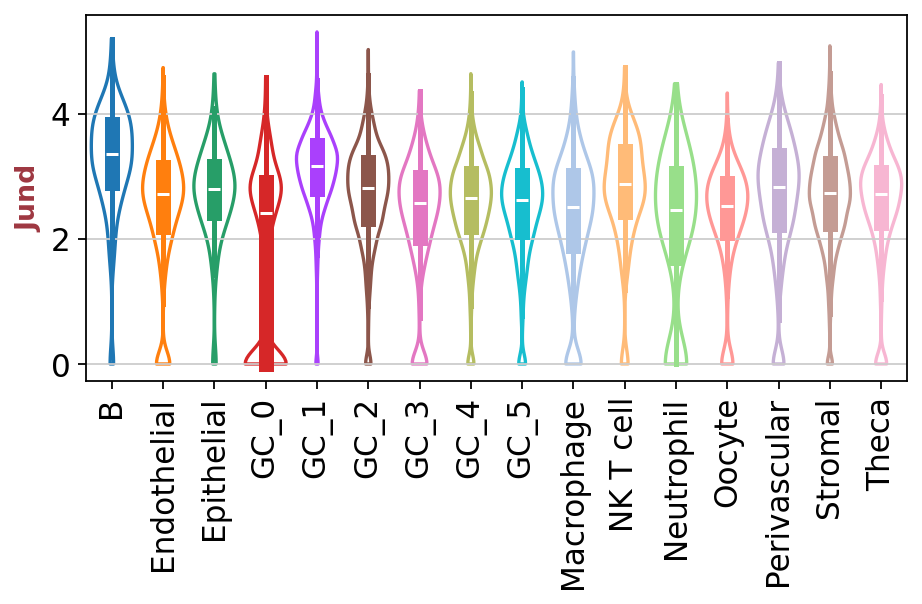

In [11]:
fig, axs = plt.subplots(1,1,figsize=(6,4),sharey=False
                       # , gridspec_kw={'wspace':0.4,'hspace':0.4}
                       )
sc.pl.violin(adata,'Jund'
             ,jitter=0.1
             ,multi_panel=False
             ,ax=axs
             ,stripplot=False,fill=False
             ,inner='box'
             ,groupby='Cluster_all'
             #,order=ordered_groups
             ,show=False
             ,rotation=90
            )
axs.set_xlabel(axs.get_xlabel(),rotation=0, ha='center',color='#9e3741',weight='bold',fontsize=12) #xlabel 类似R
axs.set_ylabel(axs.get_ylabel(), color='#9e3741',weight='bold',fontsize=12) # xtitle

# 保存图形为矢量图，这里以PDF为例
#plt.savefig('./1_quality_control/qc_plot.pdf', format='pdf', bbox_inches='tight')

plt.tight_layout() # 自动调整子图参数,使之填充整个图像区域
plt.show()


In [13]:
import json

# 读取JSON文件并转换为字典
with open('./12_drug2cell/drug2cell_mouse_ls.json', 'r') as file:
    my_dict = json.load(file)


In [20]:
##导入药物数据
#a=d2c.data.chembl()
#a.items()

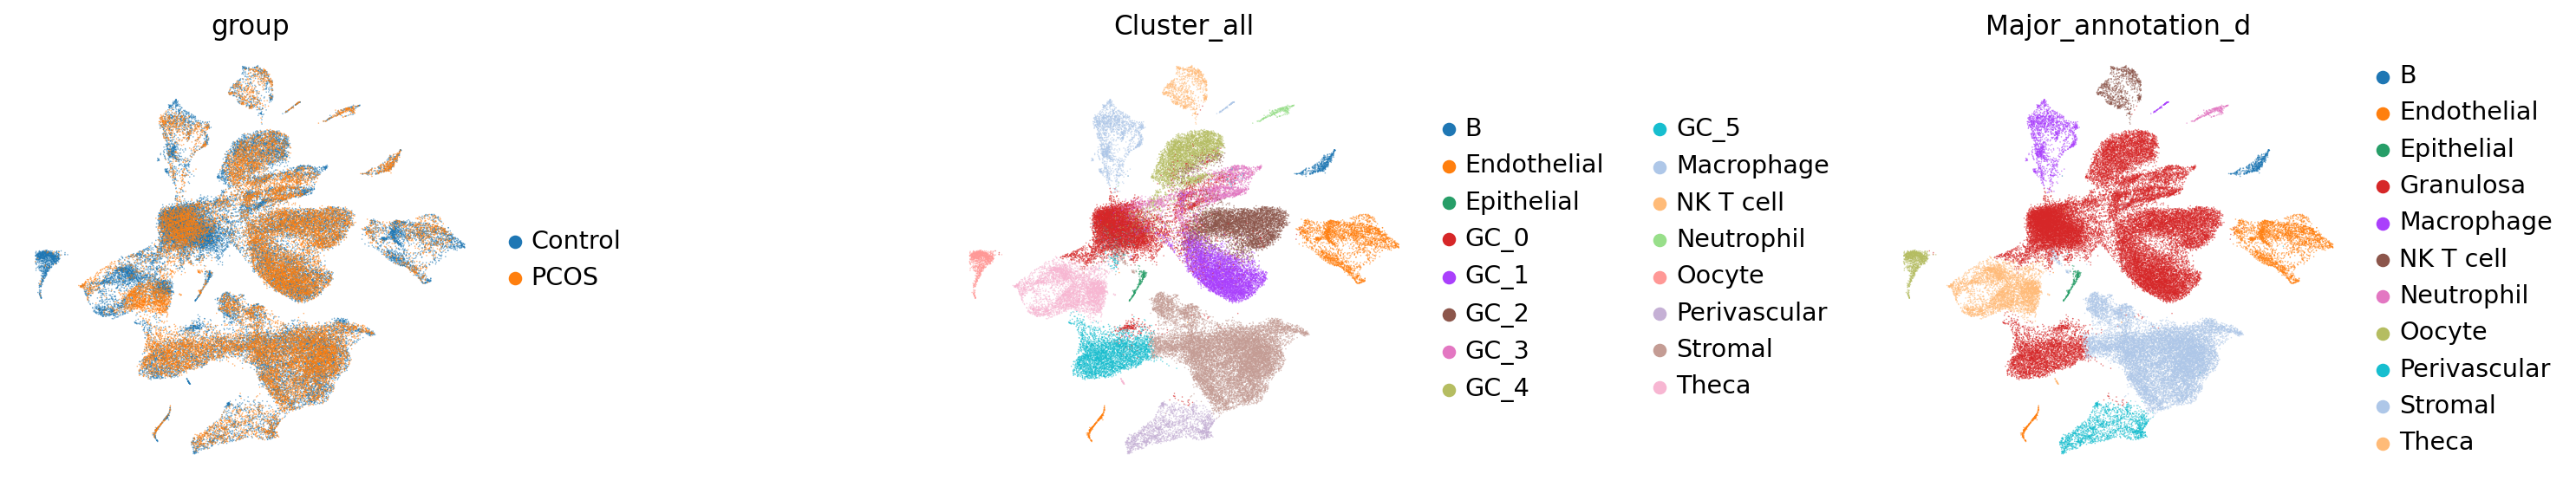

In [14]:
sc.pl.umap(adata, color=["group",'Cluster_all','Major_annotation_d'],
    #      s=1,          # 调整点的大小
    alpha=0.6,     # 调整点的透明度
    #palette='viridis',  # 设置颜色调色板
    frameon=False, # 不显示图例边框
    wspace=0.8,    # 子图之间的水平间距
    hspace=0.4     # 子图之间的垂直间距
          )


In [15]:
d2c.score(adata,targets=my_dict,use_raw=True)

In [16]:
adata.uns.keys()

dict_keys(['Major_annotation_colors', 'Major_annotation_d_colors', 'bbknn_leiden_0.5', 'bbknn_leiden_0.5_colors', 'd_harmony_leiden_0.2', 'd_harmony_leiden_0.2_colors', 'dea_manual_1', 'dendrogram_Major_annotation_d', 'dendrogram_harmony_leiden_0.2', 'group_colors', 'harmony_leiden_0.2', 'harmony_leiden_0.2_colors', 'harmony_leiden_0.5', 'harmony_leiden_0.5_colors', 'hvg', 'leiden_0.5', 'leiden_0.5_colors', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'sample_colors', 'umap', 'umap_bbknn', 'umap_harmony', 'umap_harmony_d', 'Cluster_all_colors', 'drug2cell'])

In [18]:
adata_drug=adata.uns['drug2cell']

In [20]:
adata_drug.var_names

Index(['CHEMBL411|DIETHYLSTILBESTROL', 'CHEMBL2105618|ALLYLESTRENOL',
       'CHEMBL497|CLIOQUINOL', 'CHEMBL1533|DESOGESTREL',
       'CHEMBL1201649|ESTROGENS, CONJUGATED', 'CHEMBL1382|TOLTERODINE',
       'CHEMBL521|IBUPROFEN', 'CHEMBL548|DINOPROSTONE',
       'CHEMBL12610|BENZYDAMINE', 'CHEMBL159226|MOXISYLYTE',
       ...
       'CHEMBL1201566|DARBEPOETIN ALFA.1', 'CHEMBL2010601|IVACAFTOR.1',
       'CHEMBL1229908|ETHAMIVAN.1', 'CHEMBL1200689|NITRIC OXIDE.1',
       'CHEMBL1201556|BECAPLERMIN.3',
       'CHEMBL2108709|COLLAGENASE CLOSTRIDIUM HISTOLYTICUM.2',
       'CHEMBL2108709|COLLAGENASE CLOSTRIDIUM HISTOLYTICUM.3',
       'CHEMBL4297240|ONASEMNOGENE ABEPARVOVEC.1', 'CHEMBL256997|ATALUREN.1',
       'CHEMBL3989924|LUTETIUM DOTATATE LU-177.1'],
      dtype='object', length=4276)

In [23]:
### 差异分析
sc.tl.rank_genes_groups(adata_drug
                        ,groupby='Cluster_all'
                        ,method='wilcoxon'
                        ,pts=True,use_raw=False,key_added='wilcoxon_drug')
### 导出差异分析结果
groups=adata_drug.uns['wilcoxon_drug']['names'].dtype.names

with pd.ExcelWriter('./12_drug2cell/drug_dea_results.xlsx') as writer:
    for group in groups:
        df=sc.get.rank_genes_groups_df(adata_drug,group=group,key='wilcoxon_drug')
        df['Cluster_all']=group
        ### 保存excel表格
        df.to_excel(writer,sheet_name=group)
    

In [48]:
with pd.ExcelWriter('./12_drug2cell/drug_dea_group_results.xlsx') as writer:
    cell_group_id='GC_1'
    print(f'开始GC_{cell_group_id}差异分析!')
    adata_sub=adata_drug[adata_drug.obs['Cluster_all']==cell_group_id].copy()
    key_added_index='dea_GC_'+cell_group_id
    sc.tl.rank_genes_groups(
    adata_sub
    ,groupby='group'
    ,method="wilcoxon"
    ,reference='Control'
    #,groups='PCOS'
    ,key_added=key_added_index
    ,use_raw=False  #默认就是用这个
        )
### 到处差异分析结果
    df=sc.get.rank_genes_groups_df(adata_sub,group=None,key=key_added_index)
    df.to_excel(writer,sheet_name=cell_group_id,index=False)
    print(f'保存完毕GC_{cell_group_id}细胞组间差异分析结果!')

开始GC_GC_1差异分析!
保存完毕GC_GC_1细胞组间差异分析结果!


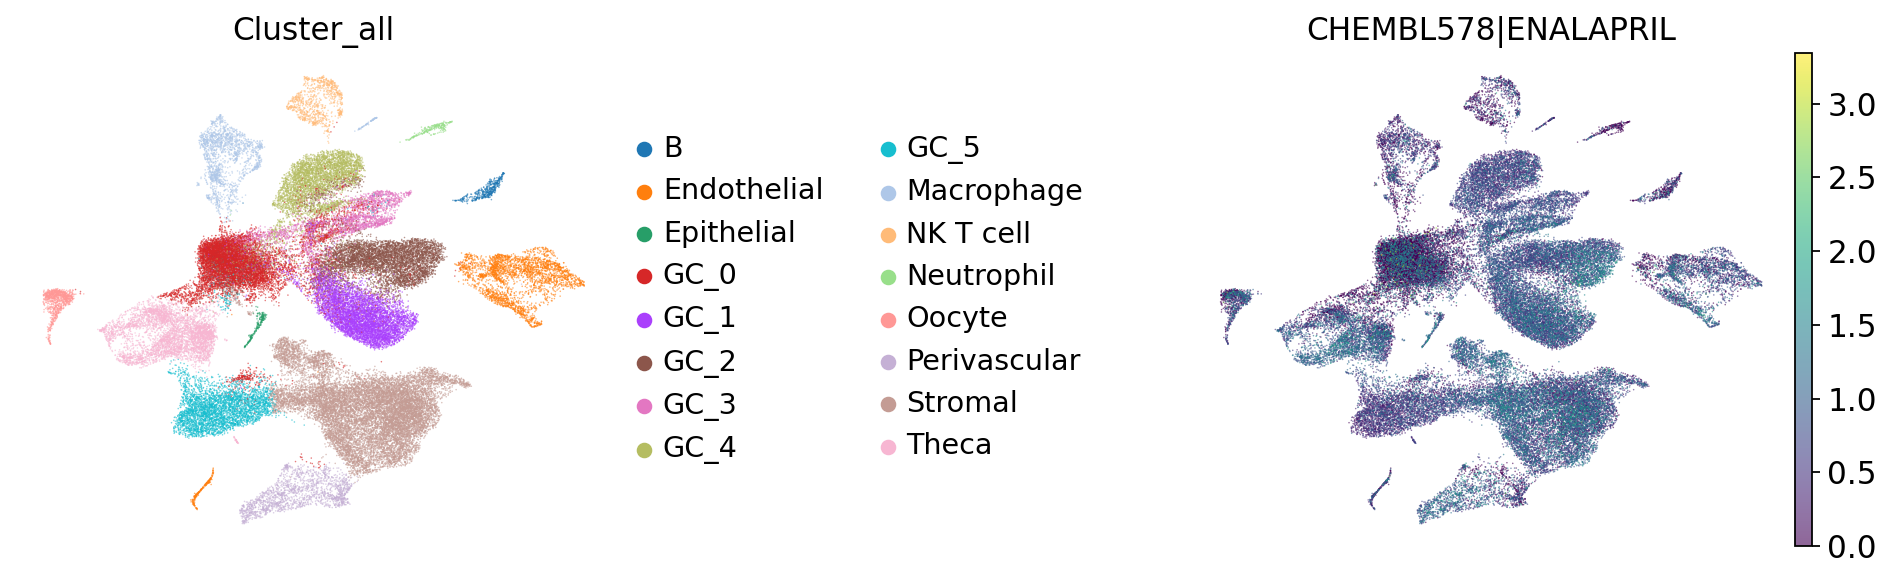

In [56]:
sc.pl.umap(adata_drug, color=['Cluster_all','CHEMBL578|ENALAPRIL'],
    #      s=1,          # 调整点的大小
    alpha=0.6,     # 调整点的透明度
    #palette='viridis',  # 设置颜色调色板
    frameon=False, # 不显示图例边框
    wspace=0.8,    # 子图之间的水平间距
    hspace=0.4     # 子图之间的垂直间距
          )

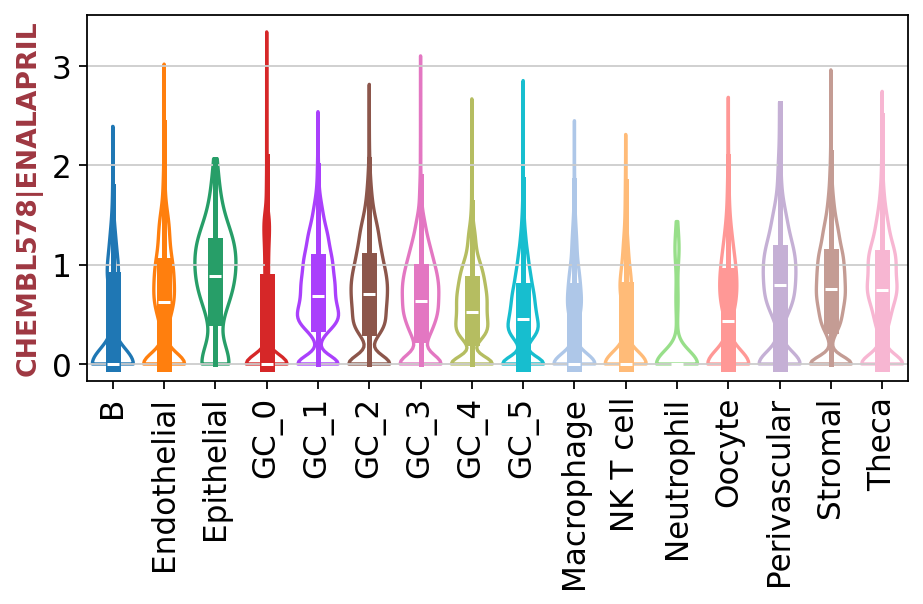

In [57]:
fig, axs = plt.subplots(1,1,figsize=(6,4),sharey=False
                       # , gridspec_kw={'wspace':0.4,'hspace':0.4}
                       )
sc.pl.violin(adata_drug,['CHEMBL578|ENALAPRIL']
             ,jitter=0.1
             ,multi_panel=False
             ,ax=axs
             ,stripplot=False,fill=False
             ,inner='box'
             ,groupby='Cluster_all'
             #,order=ordered_groups
             ,show=False
             ,rotation=90
            )
axs.set_xlabel(axs.get_xlabel(),rotation=0, ha='center',color='#9e3741',weight='bold',fontsize=12) #xlabel 类似R
axs.set_ylabel(axs.get_ylabel(), color='#9e3741',weight='bold',fontsize=12) # xtitle

# 保存图形为矢量图，这里以PDF为例
#plt.savefig('./1_quality_control/qc_plot.pdf', format='pdf', bbox_inches='tight')

plt.tight_layout() # 自动调整子图参数,使之填充整个图像区域
plt.show()


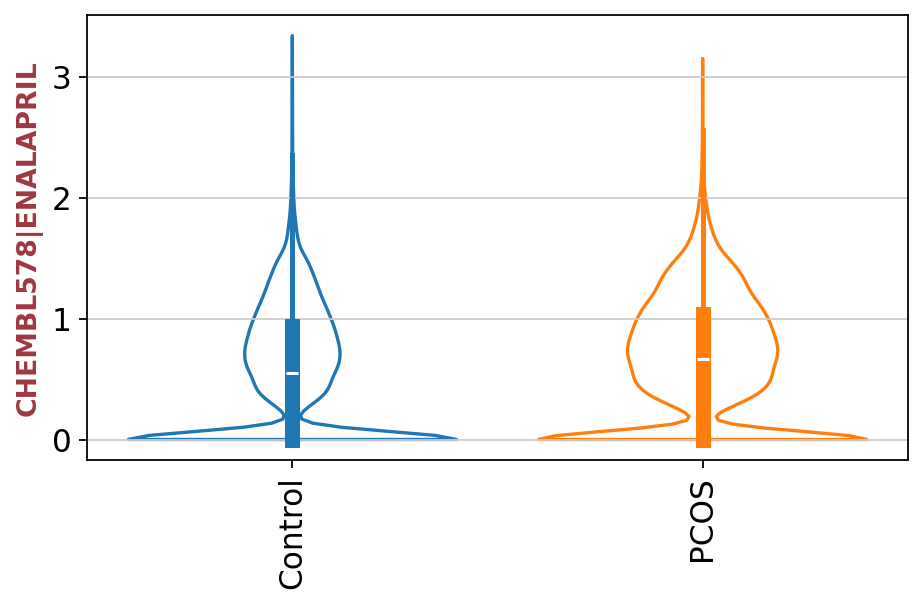

In [58]:
fig, axs = plt.subplots(1,1,figsize=(6,4),sharey=False
                       # , gridspec_kw={'wspace':0.4,'hspace':0.4}
                       )
sc.pl.violin(adata_drug,['CHEMBL578|ENALAPRIL']
             ,jitter=0.1
             ,multi_panel=False
             ,ax=axs
             ,stripplot=False,fill=False
             ,inner='box'
             ,groupby='group'
             #,order=ordered_groups
             ,show=False
             ,rotation=90
            )
axs.set_xlabel(axs.get_xlabel(),rotation=0, ha='center',color='#9e3741',weight='bold',fontsize=12) #xlabel 类似R
axs.set_ylabel(axs.get_ylabel(), color='#9e3741',weight='bold',fontsize=12) # xtitle

# 保存图形为矢量图，这里以PDF为例
#plt.savefig('./1_quality_control/qc_plot.pdf', format='pdf', bbox_inches='tight')

plt.tight_layout() # 自动调整子图参数,使之填充整个图像区域
plt.show()
